<a href="https://colab.research.google.com/github/itsacarnival94/NutritionGPT/blob/main/NutritionGPT_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Configuration and imports
%pip -q install --upgrade-strategy only-if-needed "gradio==6.20.0"
from __future__ import annotations

import csv
import json
import math
import os
import random
import time
import warnings
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path
from typing import Iterable

import gradio as gr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import torch
import torch.nn as nn
from PIL import Image, ImageFile
from IPython.display import display
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.models import EfficientNet_B0_Weights, efficientnet_b0
from tqdm.auto import tqdm

ImageFile.LOAD_TRUNCATED_IMAGES = True
warnings.filterwarnings("ignore", category=UserWarning)

SEED = 42
MAX_IMAGES = None       # None = all available overhead RGB images
IMAGE_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 8
FREEZE_EPOCHS = 1       # train the new hidden layers first
PATIENCE = 3
DOWNLOAD_WORKERS = 16
NUM_WORKERS = 2

TARGETS = ["calories", "mass", "fat", "carbs", "protein"]
UNITS = {"calories": "kcal", "mass": "g", "fat": "g", "carbs": "g", "protein": "g"}
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True

print(f"PyTorch: {torch.__version__} | Gradio: {gr.__version__} | Device: {DEVICE}")
if DEVICE.type != "cuda":
    print("GPU not detected. The notebook still works, but training will be slower.")

PyTorch: 2.11.0+cu128 | Gradio: 6.20.0 | Device: cuda


## 1. Download a Colab-sized Nutrition5k training set

The code downloads official dish labels plus only the selected overhead `rgb.png` images; it does **not** download the 181 GB video archive.

In [ ]:
# Download and prepare Nutrition5k
BUCKET = "nutrition5k_dataset"
PREFIX = "nutrition5k_dataset"
PUBLIC_ROOT = f"https://storage.googleapis.com/{BUCKET}/{PREFIX}"
LIST_API = f"https://storage.googleapis.com/storage/v1/b/{BUCKET}/o"

ROOT = Path("/content/nutrilens_nutrition5k")
META_DIR = ROOT / "metadata"
IMAGE_DIR = ROOT / "images"
META_DIR.mkdir(parents=True, exist_ok=True)
IMAGE_DIR.mkdir(parents=True, exist_ok=True)


def request_with_retry(url: str, *, params: dict | None = None, stream: bool = False,
                       timeout: tuple[int, int] = (15, 120), attempts: int = 4) -> requests.Response:
    last_error: Exception | None = None
    for attempt in range(attempts):
        try:
            response = requests.get(url, params=params, stream=stream, timeout=timeout)
            if response.status_code == 404:
                return response
            response.raise_for_status()
            return response
        except requests.RequestException as exc:
            last_error = exc
            if attempt + 1 < attempts:
                time.sleep(1.5 * (attempt + 1))
    raise RuntimeError(f"Download failed: {url}") from last_error


def download_small_file(relative_path: str, destination: Path) -> Path:
    if destination.exists() and destination.stat().st_size > 0:
        return destination
    response = request_with_retry(f"{PUBLIC_ROOT}/{relative_path}")
    if response.status_code == 404:
        raise FileNotFoundError(relative_path)
    destination.write_bytes(response.content)
    return destination


metadata_files = []
for name in ("dish_metadata_cafe1.csv", "dish_metadata_cafe2.csv"):
    metadata_files.append(download_small_file(f"metadata/{name}", META_DIR / name))

# The CSV rows have seven fixed dish-level fields followed by a variable number of ingredient fields.
rows: list[dict] = []
for path in metadata_files:
    with path.open("r", encoding="utf-8", newline="") as handle:
        for row in csv.reader(handle):
            if len(row) < 7 or not row[0].startswith("dish_"):
                continue
            try:
                rows.append({
                    "dish_id": row[0],
                    "calories": float(row[1]),
                    "mass": float(row[2]),
                    "fat": float(row[3]),
                    "carbs": float(row[4]),
                    "protein": float(row[5]),
                })
            except ValueError:
                continue

labels = pd.DataFrame(rows).drop_duplicates("dish_id").reset_index(drop=True)
labels = labels.replace([np.inf, -np.inf], np.nan).dropna(subset=TARGETS)
labels = labels[(labels[TARGETS] >= 0).all(axis=1)].reset_index(drop=True)
label_lookup = labels.set_index("dish_id").to_dict("index")


def list_rgb_objects() -> list[tuple[str, str]]:
    """Return (dish_id, object_name) pairs. Falls back cleanly if bucket listing is unavailable."""
    object_prefix = f"{PREFIX}/imagery/realsense_overhead/"
    pairs: list[tuple[str, str]] = []
    page_token: str | None = None
    try:
        while True:
            params = {"prefix": object_prefix, "maxResults": 1000}
            if page_token:
                params["pageToken"] = page_token
            response = request_with_retry(LIST_API, params=params, timeout=(15, 60))
            payload = response.json()
            for item in payload.get("items", []):
                name = item.get("name", "")
                if name.endswith("/rgb.png"):
                    dish_id = name.rsplit("/", 2)[-2]
                    if dish_id in label_lookup:
                        pairs.append((dish_id, name))
            page_token = payload.get("nextPageToken")
            if not page_token:
                break
        if not pairs:
            raise RuntimeError("No overhead RGB objects were returned by the bucket listing API.")
    except Exception as exc:
        print(f"Bucket listing unavailable ({exc}). Falling back to direct image checks.")
        pairs = [
            (dish_id, f"{object_prefix}{dish_id}/rgb.png")
            for dish_id in labels["dish_id"].tolist()
        ]
    return pairs


candidates = list_rgb_objects()
rng = random.Random(SEED)
rng.shuffle(candidates)


def valid_existing_image(path: Path) -> bool:
    if not path.exists() or path.stat().st_size < 1024:
        return False
    try:
        with Image.open(path) as image:
            image.verify()
        return True
    except Exception:
        path.unlink(missing_ok=True)
        return False


def download_rgb(pair: tuple[str, str]) -> str | None:
    dish_id, object_name = pair
    destination = IMAGE_DIR / f"{dish_id}.png"
    if valid_existing_image(destination):
        return dish_id

    url = f"https://storage.googleapis.com/{BUCKET}/{object_name}"
    try:
        response = request_with_retry(url, stream=True, attempts=3)
        if response.status_code == 404:
            return None
        temporary = destination.with_suffix(".part")
        with temporary.open("wb") as handle:
            for chunk in response.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    handle.write(chunk)
        temporary.replace(destination)
        if valid_existing_image(destination):
            return dish_id
    except Exception:
        destination.unlink(missing_ok=True)
        destination.with_suffix(".part").unlink(missing_ok=True)
    return None


target_count = len(candidates) if MAX_IMAGES is None else min(MAX_IMAGES, len(candidates))
available_ids: list[str] = []
batch_size = max(128, DOWNLOAD_WORKERS * 8)

progress = tqdm(total=target_count, desc="Downloading Nutrition5k RGB images")
for start in range(0, len(candidates), batch_size):
    if len(available_ids) >= target_count:
        break
    batch = candidates[start:start + batch_size]
    with ThreadPoolExecutor(max_workers=DOWNLOAD_WORKERS) as executor:
        futures = [executor.submit(download_rgb, pair) for pair in batch]
        for future in as_completed(futures):
            dish_id = future.result()
            if dish_id is not None:
                available_ids.append(dish_id)
                progress.update(1)
                if len(available_ids) >= target_count:
                    break
progress.close()

available_ids = list(dict.fromkeys(available_ids))[:target_count]
if len(available_ids) < 100:
    raise RuntimeError(
        f"Only {len(available_ids)} images were downloaded. Check Colab internet access and rerun this cell."
    )

manifest = labels[labels["dish_id"].isin(available_ids)].copy()
manifest["image_path"] = manifest["dish_id"].map(lambda x: str(IMAGE_DIR / f"{x}.png"))
manifest = manifest[manifest["image_path"].map(lambda x: Path(x).exists())].reset_index(drop=True)

# Prefer the official RGB split; use a deterministic random split if those files are unavailable.
def read_split(name: str) -> set[str]:
    path = META_DIR / name
    try:
        download_small_file(f"dish_ids/splits/{name}", path)
        return {line.strip() for line in path.read_text(encoding="utf-8").splitlines() if line.strip()}
    except Exception:
        return set()


official_train = read_split("rgb_train_ids.txt")
official_test = read_split("rgb_test_ids.txt")
available = set(manifest["dish_id"])
train_pool = sorted(available & official_train)
test_ids = sorted(available & official_test)

if len(train_pool) < 50 or len(test_ids) < 10:
    shuffled = sorted(available)
    rng.shuffle(shuffled)
    n_test = max(1, round(0.10 * len(shuffled)))
    n_val = max(1, round(0.15 * (len(shuffled) - n_test)))
    test_ids = shuffled[:n_test]
    val_ids = shuffled[n_test:n_test + n_val]
    train_ids = shuffled[n_test + n_val:]
else:
    rng.shuffle(train_pool)
    n_val = max(1, round(0.15 * len(train_pool)))
    val_ids = train_pool[:n_val]
    train_ids = train_pool[n_val:]

train_df = manifest[manifest["dish_id"].isin(train_ids)].reset_index(drop=True)
val_df = manifest[manifest["dish_id"].isin(val_ids)].reset_index(drop=True)
test_df = manifest[manifest["dish_id"].isin(test_ids)].reset_index(drop=True)

print(f"Labels: {len(labels):,} | Images: {len(manifest):,}")
print(f"Train: {len(train_df):,} | Validation: {len(val_df):,} | Test: {len(test_df):,}")
display(manifest[["dish_id", *TARGETS]].head())

Labels: 5,006 | Images: 3,490
Train: 2,342 | Validation: 413 | Test: 507


,dish_id,calories,mass,fat,carbs,protein
0,dish_1561662216,300.794281,193.0,12.387489,28.218290,18.633970
1,dish_1561662054,419.438782,292.0,23.838249,26.351543,25.910593
2,dish_1562008979,382.936646,290.0,22.224644,10.173570,35.345387
3,dish_1560455030,20.590000,103.0,0.148000,4.625000,0.956000
4,dish_1558372433,74.360001,143.0,0.286000,0.429000,20.020000


## 2. Dataset, hidden layers, and data loaders

The model predicts five values simultaneously. Targets are log-transformed and standardized using only the training set.

In [ ]:
# Transforms, Dataset, target normalization, and DataLoaders
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.72, 1.0), ratio=(0.9, 1.1)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.12, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_log_targets = np.log1p(train_df[TARGETS].to_numpy(dtype=np.float32))
target_mean = torch.tensor(train_log_targets.mean(axis=0), dtype=torch.float32)
target_std = torch.tensor(train_log_targets.std(axis=0), dtype=torch.float32).clamp_min(1e-6)


class NutritionDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, transform, mean: torch.Tensor, std: torch.Tensor):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform
        self.mean = mean
        self.std = std

    def __len__(self) -> int:
        return len(self.frame)

    def __getitem__(self, index: int):
        row = self.frame.iloc[index]
        with Image.open(row["image_path"]) as image:
            image = image.convert("RGB")
            image_tensor = self.transform(image)
        raw_target = torch.tensor(row[TARGETS].to_numpy(dtype=np.float32), dtype=torch.float32)
        normalized_target = (torch.log1p(raw_target) - self.mean) / self.std
        return image_tensor, normalized_target


train_dataset = NutritionDataset(train_df, train_transform, target_mean, target_std)
val_dataset = NutritionDataset(val_df, eval_transform, target_mean, target_std)
test_dataset = NutritionDataset(test_df, eval_transform, target_mean, target_std)

loader_kwargs = dict(
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=DEVICE.type == "cuda",
    persistent_workers=NUM_WORKERS > 0,
)
train_loader = DataLoader(train_dataset, shuffle=True, drop_last=len(train_dataset) >= BATCH_SIZE, **loader_kwargs)
val_loader = DataLoader(val_dataset, shuffle=False, drop_last=False, **loader_kwargs)
test_loader = DataLoader(test_dataset, shuffle=False, drop_last=False, **loader_kwargs)


class NutritionRegressor(nn.Module):
    """EfficientNet image encoder + explicit trainable hidden regression layers."""
    def __init__(self, output_size: int = 5):
        super().__init__()
        try:
            self.backbone = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
            print("Loaded EfficientNet-B0 backbone.")
        except Exception as exc:
            print(f"Pretrained weights unavailable ({exc}); training from random initialization.")
            self.backbone = efficientnet_b0(weights=None)

        feature_count = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Identity()
        self.regression_head = nn.Sequential(
            nn.Linear(feature_count, 512),
            nn.BatchNorm1d(512),
            nn.SiLU(),
            nn.Dropout(0.30),
            nn.Linear(512, 256),
            nn.SiLU(),
            nn.Dropout(0.20),
            nn.Linear(256, output_size),
        )

    def forward(self, images: torch.Tensor) -> torch.Tensor:
        features = self.backbone(images)
        return self.regression_head(features)

    def freeze_backbone(self) -> None:
        for parameter in self.backbone.parameters():
            parameter.requires_grad = False

    def unfreeze_last_blocks(self, count: int = 3) -> None:
        for parameter in self.backbone.features[-count:].parameters():
            parameter.requires_grad = True


model = NutritionRegressor(len(TARGETS)).to(DEVICE)
model.freeze_backbone()
print(model.regression_head)
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Loaded EfficientNet-B0 backbone.
Sequential(
  (0): Linear(in_features=1280, out_features=512, bias=True)
  (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): SiLU()
  (3): Dropout(p=0.3, inplace=False)
  (4): Linear(in_features=512, out_features=256, bias=True)
  (5): SiLU()
  (6): Dropout(p=0.2, inplace=False)
  (7): Linear(in_features=256, out_features=5, bias=True)
)
Trainable parameters: 789,509


## 3. Actual epoch-based training loop

This includes forward passes, loss calculation, backpropagation, optimizer steps, mixed precision, validation, learning-rate reduction, checkpointing, gradual unfreezing, and early stopping.

Epoch 1/8 train:   0%|          | 0/73 [00:00<?, ?it/s]

Epoch 1/8 valid:   0%|          | 0/13 [00:00<?, ?it/s]

Epoch 01 | train loss 0.3250 | validation loss 0.2463 | calorie MAE 78.5 kcal
Unfroze the final EfficientNet blocks for fine-tuning.


Epoch 2/8 train:   0%|          | 0/73 [00:00<?, ?it/s]

Epoch 2/8 valid:   0%|          | 0/13 [00:00<?, ?it/s]

...

Epoch 07 | train loss 0.2052 | validation loss 0.1931 | calorie MAE 68.8 kcal


Epoch 8/8 train:   0%|          | 0/73 [00:00<?, ?it/s]

Epoch 8/8 valid:   0%|          | 0/13 [00:00<?, ?it/s]

Epoch 08 | train loss 0.1940 | validation loss 0.1877 | calorie MAE 66.5 kcal


,epoch,train_loss,validation_loss,validation_mae_calories,validation_mae_mass,validation_mae_fat,validation_mae_carbs,validation_mae_protein
0,1,0.325,0.246,78.468002,53.188000,5.470,7.769,7.889
1,2,0.321,0.253,80.886002,57.870998,5.739,8.212,7.673
2,3,0.267,0.223,72.403000,51.409000,5.236,7.739,6.945
3,4,0.242,0.209,73.560997,49.325001,4.997,7.297,6.713
4,5,0.226,0.207,74.393997,50.116001,5.154,7.071,6.530
5,6,0.215,0.191,66.688004,45.929001,4.767,6.891,6.281
6,7,0.205,0.193,68.755997,44.693001,4.796,6.811,6.415
7,8,0.194,0.188,66.508003,45.800999,5.091,6.913,6.442


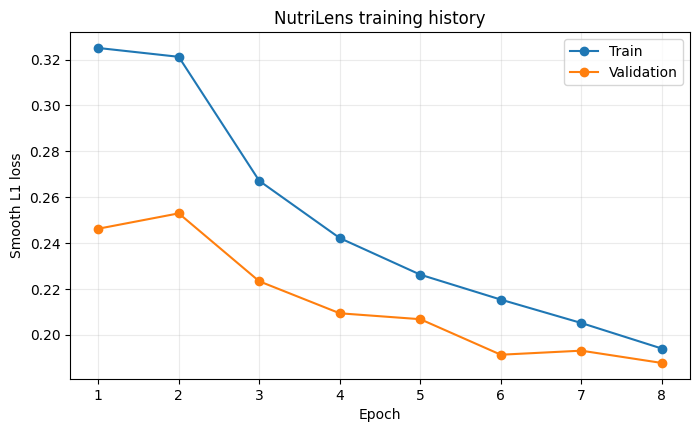

In [ ]:
# Train the network
CHECKPOINT_PATH = ROOT / "nutrilens_best.pt"
criterion = nn.SmoothL1Loss(beta=0.5)
amp_enabled = DEVICE.type == "cuda"
scaler = torch.amp.GradScaler("cuda", enabled=amp_enabled)
mean_on_device = target_mean.to(DEVICE)
std_on_device = target_std.to(DEVICE)


def make_optimizer() -> torch.optim.Optimizer:
    groups = [{"params": model.regression_head.parameters(), "lr": 3e-4}]
    backbone_params = [p for p in model.backbone.parameters() if p.requires_grad]
    if backbone_params:
        groups.append({"params": backbone_params, "lr": 3e-5})
    return torch.optim.AdamW(groups, weight_decay=1e-4)


def denormalize_targets(normalized: torch.Tensor) -> torch.Tensor:
    return torch.expm1(normalized * std_on_device + mean_on_device).clamp_min(0)


def run_epoch(loader: DataLoader, training: bool, epoch_number: int) -> tuple[float, np.ndarray]:
    model.train(training)
    if training and epoch_number < FREEZE_EPOCHS:
        model.backbone.eval()  # keep frozen BatchNorm statistics fixed

    total_loss = 0.0
    total_examples = 0
    absolute_error = torch.zeros(len(TARGETS), device=DEVICE)
    description = f"Epoch {epoch_number + 1}/{EPOCHS} {'train' if training else 'valid'}"
    progress_bar = tqdm(loader, desc=description, leave=False)

    for images, targets in progress_bar:
        images = images.to(DEVICE, non_blocking=True)
        targets = targets.to(DEVICE, non_blocking=True)

        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=amp_enabled):
                predictions = model(images)
                loss = criterion(predictions, targets)

            if training:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
                scaler.step(optimizer)
                scaler.update()

        batch_count = images.size(0)
        total_loss += loss.item() * batch_count
        total_examples += batch_count
        with torch.no_grad():
            predicted_raw = denormalize_targets(predictions)
            target_raw = denormalize_targets(targets)
            absolute_error += (predicted_raw - target_raw).abs().sum(dim=0)

        progress_bar.set_postfix(loss=f"{total_loss / max(total_examples, 1):.4f}")

    return total_loss / max(total_examples, 1), (absolute_error / max(total_examples, 1)).cpu().numpy()


optimizer = make_optimizer()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=1, min_lr=1e-6
)

history: list[dict] = []
best_validation_loss = math.inf
stale_epochs = 0

for epoch in range(EPOCHS):
    if epoch == FREEZE_EPOCHS:
        model.unfreeze_last_blocks(count=3)
        optimizer = make_optimizer()
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.5, patience=1, min_lr=1e-6
        )
        print("Unfroze the final EfficientNet blocks for fine-tuning.")

    train_loss, train_mae = run_epoch(train_loader, training=True, epoch_number=epoch)
    validation_loss, validation_mae = run_epoch(val_loader, training=False, epoch_number=epoch)
    scheduler.step(validation_loss)

    row = {
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "validation_loss": validation_loss,
        **{f"validation_mae_{name}": value for name, value in zip(TARGETS, validation_mae)},
    }
    history.append(row)
    print(
        f"Epoch {epoch + 1:02d} | train loss {train_loss:.4f} | "
        f"validation loss {validation_loss:.4f} | calorie MAE {validation_mae[0]:.1f} kcal"
    )

    if validation_loss < best_validation_loss - 1e-4:
        best_validation_loss = validation_loss
        stale_epochs = 0
        torch.save({
            "model_state": model.state_dict(),
            "target_mean": target_mean,
            "target_std": target_std,
            "targets": TARGETS,
            "image_size": IMAGE_SIZE,
            "validation_mae": validation_mae,
        }, CHECKPOINT_PATH)
    else:
        stale_epochs += 1
        if stale_epochs >= PATIENCE:
            print("Early stopping triggered.")
            break

history_df = pd.DataFrame(history)
display(history_df.round(3))

plt.figure(figsize=(8, 4.5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train")
plt.plot(history_df["epoch"], history_df["validation_loss"], marker="o", label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Smooth L1 loss")
plt.title("NutriLens training history")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

## 4. Evaluate the saved model

In [ ]:
# Load the best checkpoint and evaluate on held-out images
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint["model_state"])
model.eval()

test_loss, test_mae = run_epoch(test_loader, training=False, epoch_number=max(len(history), 1) - 1)
metrics = pd.DataFrame({
    "Output": ["Calories", "Dish mass", "Fat", "Carbs", "Protein"],
    "Test MAE": np.round(test_mae, 2),
    "Unit": ["kcal", "g", "g", "g", "g"],
})
display(metrics)
print(f"Saved checkpoint: {CHECKPOINT_PATH}")

Epoch 8/8 valid:   0%|          | 0/16 [00:00<?, ?it/s]

,Output,Test MAE,Unit
0,Calories,71.769997,kcal
1,Dish mass,47.740002,g
2,Fat,5.350000,g
3,Carbohydrates,8.410000,g
4,Protein,7.210000,g


Saved checkpoint: /content/nutrilens_nutrition5k/nutrilens_best.pt


## 5. Launch the aesthetic food-image app

In [ ]:
# Gradio front end
inference_transform = eval_transform
metric_error = {name: float(value) for name, value in zip(TARGETS, test_mae)}


def predict_image(image: Image.Image | None):
    if image is None:
        return "<div class='empty-state'>Upload or photograph a meal first.</div>", pd.DataFrame()

    image = image.convert("RGB")
    image_tensor = inference_transform(image).unsqueeze(0).to(DEVICE)
    with torch.inference_mode():
        with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=amp_enabled):
            normalized_prediction = model(image_tensor)
        values = denormalize_targets(normalized_prediction)[0].cpu().numpy()

    prediction = {name: float(value) for name, value in zip(TARGETS, values)}
    cards = "".join(
        f"""
        <div class="metric-card">
          <div class="metric-label">{label}</div>
          <div class="metric-value">{prediction[key]:,.1f}</div>
          <div class="metric-unit">{unit}</div>
        </div>
        """
        for key, label, unit in [
            ("calories", "Calories", "kcal"),
            ("mass", "Estimated mass", "g"),
            ("protein", "Protein", "g"),
            ("carbs", "Carbs", "g"),
            ("fat", "Fat", "g"),
        ]
    )
    html = f"""
    <div class="result-shell">
      <div class="result-title">Estimated nutrition</div>
      <div class="metric-grid">{cards}</div>
      <div class="result-note">Model estimates from one RGB photo. Portion size, hidden ingredients, and cooking oils can cause substantial error.</div>
    </div>
    """

    table = pd.DataFrame({
        "Nutrient": ["Calories", "Dish mass", "Fat", "Carbs", "Protein"],
        "Estimate": [
            round(prediction["calories"], 1), round(prediction["mass"], 1),
            round(prediction["fat"], 1), round(prediction["carbs"], 1),
            round(prediction["protein"], 1),
        ],
        "Unit": ["kcal", "g", "g", "g", "g"],
        "Held-out MAE": [
            round(metric_error["calories"], 1), round(metric_error["mass"], 1),
            round(metric_error["fat"], 1), round(metric_error["carbs"], 1),
            round(metric_error["protein"], 1),
        ],
    })
    return html, table


CSS = """
.gradio-container {max-width: 1080px !important; margin: auto !important;}
.hero {padding: 30px 34px; border-radius: 24px; background: linear-gradient(135deg, #111827, #253047); color: white; margin-bottom: 18px; box-shadow: 0 18px 45px rgba(15,23,42,.18);}
.hero h1 {font-size: 38px; line-height: 1.05; margin: 0 0 10px 0; letter-spacing: -1.2px;}
.hero p {margin: 0; opacity: .82; font-size: 16px;}
.result-shell {padding: 18px; border: 1px solid rgba(148,163,184,.25); border-radius: 10px; background: rgba(255,255,255,.74); box-shadow: 0 14px 35px rgba(15,23,42,.08); box-sizing: border-box; width: 100%; overflow: hidden;}
.result-title {font-weight: 750; font-size: 20px; margin-bottom: 14px;}
.metric-grid {display: grid; grid-template-columns: repeat(5, minmax(0, 1fr)); gap: 12px; width: 100%; box-sizing: border-box;}
.metric-card {padding: 16px 12px; border-radius: 18px; background: linear-gradient(180deg, #ffffff, #f8fafc); border: 1px solid #e2e8f0; text-align: center; min-width: 0; box-sizing: border-box;}
.metric-label {font-size: 12px; color: #64748b; min-height: 34px;}
.metric-value {font-size: 25px; font-weight: 800; letter-spacing: -.6px; color: #0f172a; overflow-wrap: break-word;}
.metric-unit {font-size: 12px; color: #64748b;}
.result-note {font-size: 12px; color: #64748b; margin-top: 14px; line-height: 1.5;}
.empty-state {padding: 48px 20px; border-radius: 5px; border: 1px dashed #cbd5e1; color: #64748b; text-align: center; background: #f8fafc;}
@media (max-width: 760px) {.metric-grid {grid-template-columns: repeat(2, 1fr);} .hero h1 {font-size: 30px;}}
"""

with gr.Blocks(title="NutritionGPT") as demo:
    gr.HTML("""
    <div class="hero">
      <h1>NutritionGPT</h1>
      <p>Upload one food photo to estimate calories, portion mass, protein, carbohydrates, and fat.</p>
    </div>
    """)
    with gr.Row(equal_height=True):
        with gr.Column(scale=5):
            food_image = gr.Image(
                label="Food image",
                type="pil",
                sources=["upload", "webcam", "clipboard"],
                height=420,
            )
            analyze_button = gr.Button("Analyze nutrition", variant="primary", size="lg")
        with gr.Column(scale=7):
            result_cards = gr.HTML("<div class='empty-state'>Your prediction will appear here.</div>")
            result_table = gr.Dataframe(
                headers=["Nutrient", "Estimate", "Unit", "Held-out MAE"],
                datatype=["str", "number", "str", "number"],
                interactive=False,
                wrap=True,
            )
    analyze_button.click(predict_image, inputs=food_image, outputs=[result_cards, result_table])

# Colab will display an embedded app and a share link.
demo.queue().launch(share=True, theme=gr.themes.Soft(), css=CSS)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://28f656913bae5e6299.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
